## 패키지 선언

In [1]:
import torch
import numpy as np
import torch.nn as nn
import torchvision.datasets as dataset
import torchvision.transforms as transform
from torch.utils.data import DataLoader

## Dataset 선언

In [2]:
# Training dataset 다운로드
CIFAR10_train = dataset.CIFAR10(root = "./", # 데이터셋을 저장할 위치
                            train = True,
                            transform = transform.ToTensor(),
                            download = True)
# Testing dataset 다운로드
CIFAR10_test = dataset.CIFAR10(root = "./",
                            train = False,
                            transform = transform.ToTensor(),
                            download = True)

100%|██████████| 170498071/170498071 [00:04<00:00, 38879414.85it/s]


Extracting ./cifar-10-python.tar.gz to ./
Files already downloaded and verified


## CIFAR10 데이터셋 형상 확인

50000
torch.Size([3, 32, 32])
6


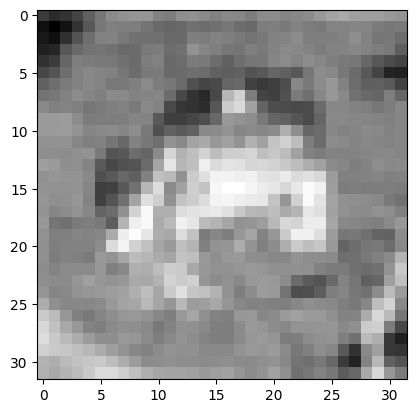

In [3]:
import matplotlib.pyplot as plt
print(len(CIFAR10_train))     # training dataset 개수 확인

first_data = CIFAR10_train[0]
print(first_data[0].shape)  # 첫번째 data의 형상 확인
print(first_data[1])        # 첫번째 data의 정답 확인

plt.imshow(first_data[0][0,:,:], cmap='gray')
plt.show()

## Multi Layer Perceptron 모델 정의: 5-layer

In [29]:
class MLP (nn.Module):
  def __init__(self):
    super(MLP, self).__init__()

    self.fc1 = nn.Linear(3072, 500)
    self.fc2 = nn.Linear(500, 500)
    self.fc3 = nn.Linear(500, 500)
    self.fc4 = nn.Linear(500, 500)
    self.fc5 = nn.Linear(500, 500)
    self.fc6 = nn.Linear(500, 10)
    self.relu = nn.ReLU()
    self.bn = nn.BatchNorm1d(500)
    self.dropout = nn.Dropout(0.1)

    torch.nn.init.xavier_normal_(self.fc1.weight.data)
    torch.nn.init.xavier_normal_(self.fc2.weight.data)
    torch.nn.init.xavier_normal_(self.fc3.weight.data)
    torch.nn.init.xavier_normal_(self.fc4.weight.data)
    torch.nn.init.xavier_normal_(self.fc5.weight.data)

  def forward(self, x):
    # print(x.shape)

    x = x.view(-1, 3072) # 이미지 평탄화

    y = self.relu(self.bn(self.fc1(x)))
    y = self.relu(self.bn(self.fc2(y)))
    y = self.relu(self.bn(self.fc3(y)))
    y = self.relu(self.bn(self.fc4(y)))
    y = self.relu(self.bn(self.fc5(y)))
    y = self.dropout(y)
    y = self.fc6(y)
    return y

## Hyper-parameters 지정

In [34]:
batch_size = 200
learning_rate = 0.1
training_epochs = 20
loss_function = nn.CrossEntropyLoss()
network = MLP()
optimizer = torch.optim.SGD(network.parameters(), lr = learning_rate)

scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10], gamma=0.1)

data_loader = DataLoader(dataset=CIFAR10_train,
                         batch_size=batch_size,
                         shuffle=True,
                         drop_last=True)

## Perceptron 학습을 위한 반복문 선언

In [35]:
for epoch in range(training_epochs):
  avg_cost = 0
  total_batch = len(data_loader)

  for img, label in data_loader:

    pred = network(img)

    loss = loss_function(pred, label)
    optimizer.zero_grad() # gradient 초기화
    loss.backward()
    optimizer.step()

    avg_cost += loss / total_batch
  scheduler.step()
  print('Epoch: %d Loss = %f'%(epoch+1, avg_cost))

print('Learning finished')

Epoch: 1 Loss = 1.633517
Epoch: 2 Loss = 1.389112
Epoch: 3 Loss = 1.257979
Epoch: 4 Loss = 1.152785
Epoch: 5 Loss = 1.058776
Epoch: 6 Loss = 0.971739
Epoch: 7 Loss = 0.885059
Epoch: 8 Loss = 0.805277
Epoch: 9 Loss = 0.739029
Epoch: 10 Loss = 0.664789
Epoch: 11 Loss = 0.423208
Epoch: 12 Loss = 0.340543
Epoch: 13 Loss = 0.301458
Epoch: 14 Loss = 0.275615
Epoch: 15 Loss = 0.253097
Epoch: 16 Loss = 0.234496
Epoch: 17 Loss = 0.219148
Epoch: 18 Loss = 0.201575
Epoch: 19 Loss = 0.187582
Epoch: 20 Loss = 0.173717
Learning finished


##Test Data 적용

In [36]:
with torch.no_grad():
  network.eval()
  img_test = torch.tensor(np.transpose(CIFAR10_test.data,(0,3,1,2))) / 255.
  label_test = torch.tensor(CIFAR10_test.targets)

  prediction = network(img_test) # 전체 test data를 한번에 계산

  correct_prediction = torch.argmax(prediction, 1) == label_test
  accuracy = correct_prediction.float().mean()
  print('Accuracy:', accuracy.item())

Accuracy: 0.17020000517368317


## Weight parameter 저장하기/불러오기

In [8]:
torch.save(network.state_dict(), "./mlp_mnist.pth")